In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import scipy.stats as stats


In [2]:
hypotheses_df = pd.read_csv('dataframes/hypotheses_us.csv', sep = ';')
orders_df = pd.read_csv('dataframes/orders_us.csv', parse_dates = ['date'])
visists_df = pd.read_csv('dataframes/visits_us.csv', parse_dates = ['date'])

In [3]:
hypotheses_df.info()
orders_df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Hypothesis  9 non-null      object
 1   Reach       9 non-null      int64 
 2   Impact      9 non-null      int64 
 3   Confidence  9 non-null      int64 
 4   Effort      9 non-null      int64 
dtypes: int64(4), object(1)
memory usage: 488.0+ bytes
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1197 entries, 0 to 1196
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   transactionId  1197 non-null   int64         
 1   visitorId      1197 non-null   int64         
 2   date           1197 non-null   datetime64[ns]
 3   revenue        1197 non-null   float64       
 4   group          1197 non-null   object        
dtypes: datetime64[ns](1), float64(1), int64(2), object(1)
memory usage: 46.9+ KB


In [4]:
visists_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 62 entries, 0 to 61
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   date    62 non-null     datetime64[ns]
 1   group   62 non-null     object        
 2   visits  62 non-null     int64         
dtypes: datetime64[ns](1), int64(1), object(1)
memory usage: 1.6+ KB


In [5]:
hypotheses_df.columns = hypotheses_df.columns.str.lower()
orders_df.columns = orders_df.columns.str.lower()
visists_df.columns = visists_df.columns.str.lower()

# Parte 1

In [6]:
hypotheses_df['ICE'] = hypotheses_df['impact'] * hypotheses_df['confidence'] / hypotheses_df['effort']

print(hypotheses_df.sort_values(by='ICE', ascending=False))

                                          hypothesis  reach  impact  \
8  Launch a promotion that gives users discounts ...      1       9   
0  Add two new channels for attracting traffic. T...      3      10   
7  Add a subscription form to all the main pages....     10       7   
6  Show banners with current offers and sales on ...      5       3   
2  Add product recommendation blocks to the store...      8       3   
1  Launch your own delivery service. This will sh...      2       5   
5  Add a customer review page. This will increase...      3       2   
3  Change the category structure. This will incre...      8       3   
4  Change the background color on the main page. ...      3       1   

   confidence  effort        ICE  
8           9       5  16.200000  
0           8       6  13.333333  
7           8       5  11.200000  
6           8       3   8.000000  
2           7       3   7.000000  
1           4      10   2.000000  
5           2       3   1.333333  
3        

In [7]:
hypotheses_df['RICE'] = (hypotheses_df['reach'] * hypotheses_df['impact'] * hypotheses_df['confidence']) / hypotheses_df['effort']
print(hypotheses_df.sort_values(by='RICE', ascending=False))

                                          hypothesis  reach  impact  \
7  Add a subscription form to all the main pages....     10       7   
2  Add product recommendation blocks to the store...      8       3   
0  Add two new channels for attracting traffic. T...      3      10   
6  Show banners with current offers and sales on ...      5       3   
8  Launch a promotion that gives users discounts ...      1       9   
3  Change the category structure. This will incre...      8       3   
1  Launch your own delivery service. This will sh...      2       5   
5  Add a customer review page. This will increase...      3       2   
4  Change the background color on the main page. ...      3       1   

   confidence  effort        ICE   RICE  
7           8       5  11.200000  112.0  
2           7       3   7.000000   56.0  
0           8       6  13.333333   40.0  
6           8       3   8.000000   40.0  
8           9       5  16.200000   16.2  
3           3       8   1.125000    9

### É percebido que quando é considerado o alcance as hipoteses mudam a prioridade, visto que outras que tem um impacto menor tem um alcance astronomico como é o caso da 7 que tem reach 10. Já outras como a 8 apesar de trazerem bom impacto e confiança o alcance é pequeno por ser algo extremamente nichado.  

In [8]:
visists_df.sample(10)


,date,group,visits
24,2019-08-25,A,621
25,2019-08-26,A,722
16,2019-08-17,A,412
10,2019-08-11,A,718
21,2019-08-22,A,609
22,2019-08-23,A,468
29,2019-08-30,A,490
55,2019-08-25,B,679
57,2019-08-27,B,720
60,2019-08-30,B,490


In [9]:
orders_df.sample(10)

,transactionid,visitorid,date,revenue,group
631,3448552908,960782649,2019-08-20,295.2,A
66,4919758,1217561296,2019-08-01,40.2,B
87,2304731149,2295217812,2019-08-22,10.9,B
807,2740953457,3102053760,2019-08-05,20.2,A
183,2234615357,1741803981,2019-08-23,90.3,B
478,469964133,537599508,2019-08-24,215.8,A
683,653973461,2231749745,2019-08-29,10.3,A
797,1595002579,2744017357,2019-08-05,85.0,A
1161,2961555325,325179089,2019-08-14,20.9,B
641,4016803793,366673373,2019-08-04,5.7,A


# Parte 2

### Tarefa 1

  group  revenue
0     A  64554.9
1     B  92840.6


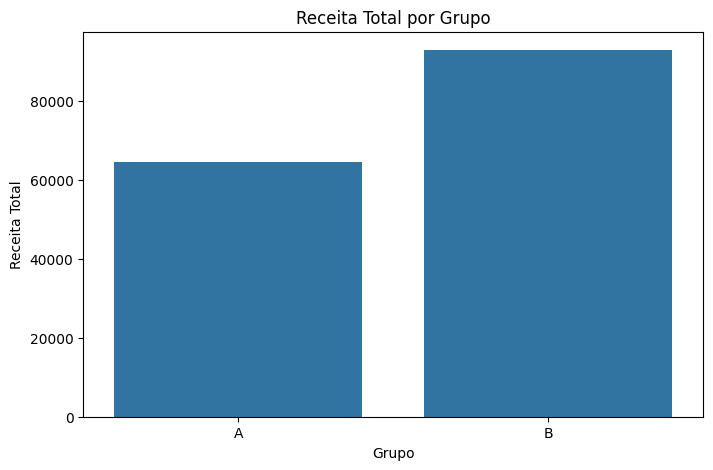

In [10]:
# Calculando receita acumulada por grupo.
revenue_by_group = orders_df.groupby('group')['revenue'].sum().reset_index()
print(revenue_by_group)
plt.figure(figsize=(8, 5))
sns.barplot(x='group', y='revenue', data=revenue_by_group)
plt.title('Receita Total por Grupo')
plt.xlabel('Grupo')
plt.ylabel('Receita Total')
plt.show()

### Pelo gráfico percebe que o grupo B teve maior receita total, porém não necessariamente significa que teve maior lucro, é necessário analisar custos. Porém com base no que foi apresentado até então o grupo B traz mais benefícios.


## Tarefa 2

In [11]:
# Calculando ticket médio por grupo.
average_ticket_by_group = orders_df.groupby(['date', 'group']).agg({'revenue': 'sum', 'transactionid': 'nunique'}).reset_index()
average_ticket_by_group['average_ticket'] = average_ticket_by_group['revenue'] / average_ticket_by_group['transactionid']

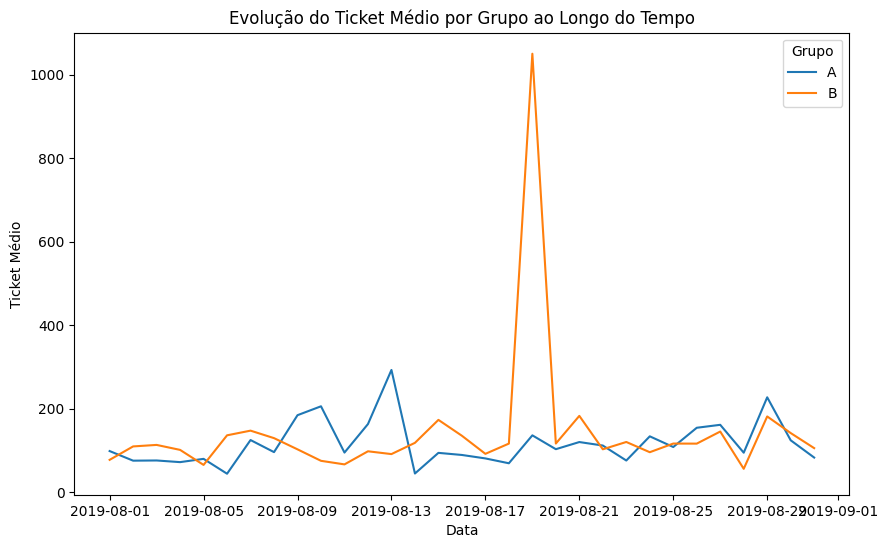

In [12]:
plt.figure(figsize=(10, 6))
sns.lineplot(x='date', y='average_ticket', hue='group', data=average_ticket_by_group)
plt.title('Evolução do Ticket Médio por Grupo ao Longo do Tempo')
plt.xlabel('Data')
plt.ylabel('Ticket Médio')
plt.legend(title='Grupo')
plt.show()

## Tarefa 3

In [13]:
# Calculando diferença de tamanho relativa de ambos os grupos.

average_ticket_by_group = orders_df.groupby(['date', 'group']).agg({'revenue': 'sum', 'transactionid': 'nunique'}).reset_index()
average_ticket_by_group['average_ticket'] = average_ticket_by_group['revenue'] / average_ticket_by_group['transactionid']
average_ticket_group_A = average_ticket_by_group[average_ticket_by_group['group'] == 'A']
average_ticket_group_B = average_ticket_by_group[average_ticket_by_group['group'] == 'B']
average_ticket_group_A['cumulative_sum'] = average_ticket_group_A['average_ticket'].cumsum()
average_ticket_group_B['cumulative_sum'] = average_ticket_group_B['average_ticket'].cumsum()
average_ticket_merged = pd.merge(average_ticket_group_A[['date', 'cumulative_sum']], average_ticket_group_B[['date', 'cumulative_sum']], on='date', suffixes=('_A', '_B'))
average_ticket_merged['relative_difference'] = (average_ticket_merged['cumulative_sum_B'] - average_ticket_merged['cumulative_sum_A']) / average_ticket_merged['cumulative_sum_A']

print(average_ticket_merged.head())

        date  cumulative_sum_A  cumulative_sum_B  relative_difference
0 2019-08-01         98.200000         77.142857            -0.214431
1 2019-08-02        173.375000        186.467857             0.075518
2 2019-08-03        249.008333        299.392857             0.202341
3 2019-08-04        320.670833        400.410504             0.248665
4 2019-08-05        400.194833        465.410504             0.162960


C:\Users\João\AppData\Local\Temp\ipykernel_28108\3559206681.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  average_ticket_group_A['cumulative_sum'] = average_ticket_group_A['average_ticket'].cumsum()
C:\Users\João\AppData\Local\Temp\ipykernel_28108\3559206681.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  average_ticket_group_B['cumulative_sum'] = average_ticket_group_B['average_ticket'].cumsum()


#### Aqui já conseguimos verificar que o fato de o B ter tido uma receita maior foi o pico que teve entre os dias 18 e 20 que fizeram com que o valor total ficasse maior, mas o A teve uma constância melhor.

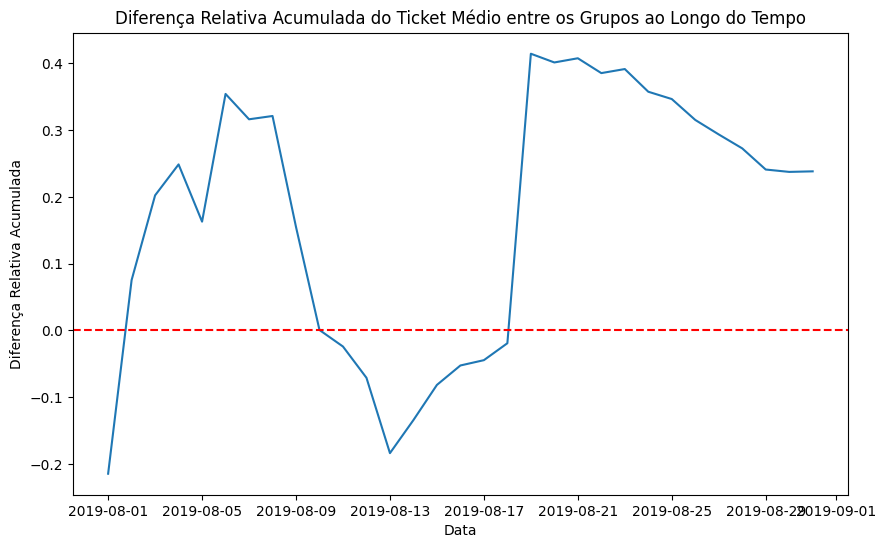

In [14]:
plt.figure(figsize=(10, 6))
sns.lineplot(x='date', y='relative_difference', data=average_ticket_merged)
plt.title('Diferença Relativa Acumulada do Ticket Médio entre os Grupos ao Longo do Tempo')
plt.xlabel('Data')
plt.ylabel('Diferença Relativa Acumulada')
plt.axhline(0, color='red', linestyle='--')
plt.show()

##### Aqui já conseguimos ver que no geral o A teve uma relação melhor com o passar do teste, o que traz uma maior confiança para investimento no teste A a um primeiro momento. Embora pelo que foi visto nos testes até agora fica mais claro a questão de que a diferença foi muito pequena para que de fato haja preferência em algum modelo específico.

## Tarefa 4

In [15]:
# Calculando a taxa de conversão de cada grupo como a proporção de pedidos em relação ao número de visitas.
visits_by_group = visists_df.groupby(['date', 'group']).agg({'visits': 'sum'}).reset_index()
orders_by_group = orders_df.groupby(['date', 'group']).agg({'transactionid': 'nunique'}).reset_index()
conversion_data = pd.merge(visits_by_group, orders_by_group, on=['date', 'group'], how='left')
conversion_data['conversion_rate'] = conversion_data['transactionid'] / conversion_data['visits']

print(conversion_data.head())

        date group  visits  transactionid  conversion_rate
0 2019-08-01     A     719             24         0.033380
1 2019-08-01     B     713             21         0.029453
2 2019-08-02     A     619             20         0.032310
3 2019-08-02     B     581             24         0.041308
4 2019-08-03     A     507             24         0.047337


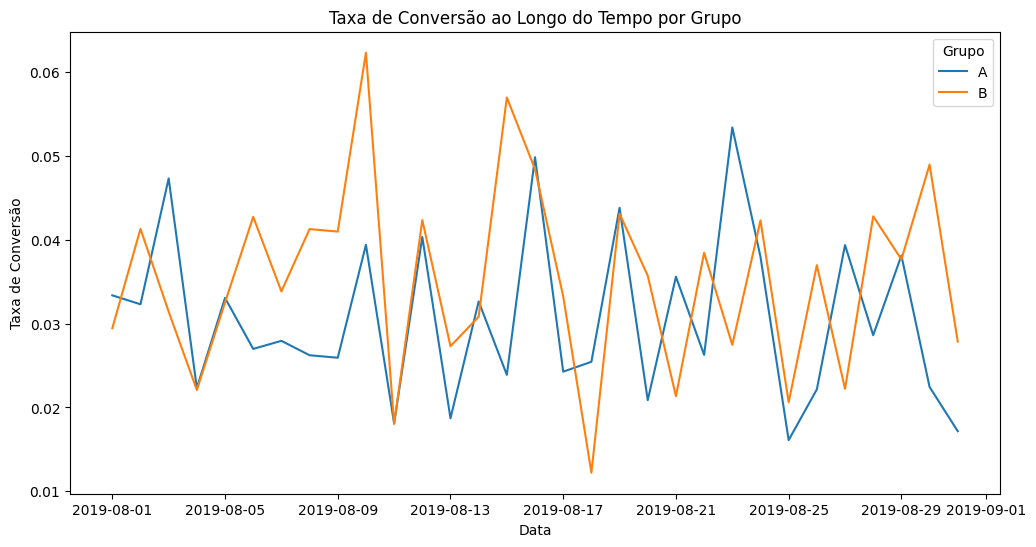

In [16]:
#plotando gráfico comparativo da taxa de conversão ao longo do tempo para ambos os grupos.

plt.figure(figsize=(12, 6))
sns.lineplot(x='date', y='conversion_rate', hue='group', data=conversion_data)
plt.title('Taxa de Conversão ao Longo do Tempo por Grupo')
plt.xlabel('Data')
plt.ylabel('Taxa de Conversão')
plt.legend(title='Grupo')
plt.show()

#### Com base na última análise pode ser verificado que o grupo B tem maior taxa de conversão com o passar dos dias, passando a entender que ele é o mais interessante. Embora como constatado anteriormente, ainda acho a diferença muito pequena para que um de fato leve vantagem sobre o outro. 

## Tarefa 5

In [17]:
# Comparação cumulativa entre os grupos A e B para a taxa de conversão.
group_a = conversion_data[conversion_data['group'] == 'A'].sort_values('date')
group_b = conversion_data[conversion_data['group'] == 'B'].sort_values('date')
group_a['cumulative_orders'] = group_a['transactionid'].cumsum()
group_a['cumulative_visits'] = group_a['visits'].cumsum()
group_a['cumulative_conversion'] = group_a['cumulative_orders'] / group_a['cumulative_visits']

group_b['cumulative_orders'] = group_b['transactionid'].cumsum()
group_b['cumulative_visits'] = group_b['visits'].cumsum()
group_b['cumulative_conversion'] = group_b['cumulative_orders'] / group_b['cumulative_visits']

print(group_a.head())
print(group_b.head())

        date group  visits  transactionid  conversion_rate  cumulative_orders  \
0 2019-08-01     A     719             24         0.033380                 24   
2 2019-08-02     A     619             20         0.032310                 44   
4 2019-08-03     A     507             24         0.047337                 68   
6 2019-08-04     A     717             16         0.022315                 84   
8 2019-08-05     A     756             25         0.033069                109   

   cumulative_visits  cumulative_conversion  
0                719               0.033380  
2               1338               0.032885  
4               1845               0.036856  
6               2562               0.032787  
8               3318               0.032851  
        date group  visits  transactionid  conversion_rate  cumulative_orders  \
1 2019-08-01     B     713             21         0.029453                 21   
3 2019-08-02     B     581             24         0.041308                 

In [18]:
combined_data = group_a[['date', 'cumulative_conversion']].merge(
    group_b[['date', 'cumulative_conversion']], 
    on='date', suffixes=('_A', '_B')
)

# Calcular diferença relativa
combined_data['relative_difference'] = ((combined_data['cumulative_conversion_B'] - combined_data['cumulative_conversion_A']) / combined_data['cumulative_conversion_A']) * 100

print(combined_data.head())

        date  cumulative_conversion_A  cumulative_conversion_B  \
0 2019-08-01                 0.033380                 0.029453   
1 2019-08-02                 0.032885                 0.034776   
2 2019-08-03                 0.036856                 0.033833   
3 2019-08-04                 0.032787                 0.030315   
4 2019-08-05                 0.032851                 0.030793   

   relative_difference  
0           -11.763675  
1             5.750316  
2            -8.204463  
3            -7.539837  
4            -6.265943  


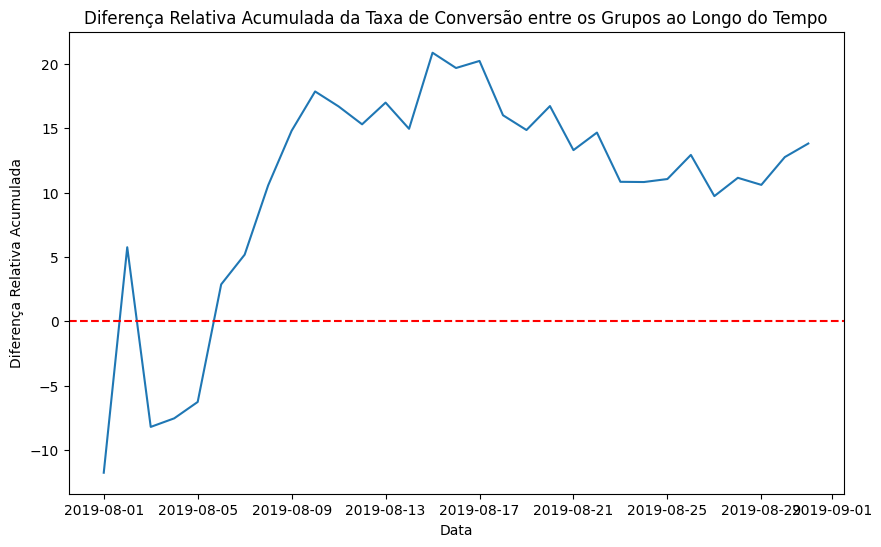

In [19]:
#plotando gráfico comparativo da diferença relativa acumulada da taxa de conversão entre os grupos ao longo do tempo.
plt.figure(figsize=(10, 6))
sns.lineplot(x='date', y='relative_difference', data=combined_data)
plt.title('Diferença Relativa Acumulada da Taxa de Conversão entre os Grupos ao Longo do Tempo')
plt.xlabel('Data')
plt.ylabel('Diferença Relativa Acumulada')
plt.axhline(0, color='red', linestyle='--')
plt.show()

#### Aqui novamente vemos vantagem no grupo A. Já foi uma diferença mais considerável podendo tornar um teste de fato mais efetivo que outro.

## Tarefa 6

In [20]:
#Calculando percentil 95 e 99 de número de pedido por usuário.
orders_by_user = orders_df.groupby('visitorid')['transactionid'].nunique().reset_index(name='num_orders')
print(orders_by_user.head())
percentile_95 = np.percentile(orders_by_user['num_orders'], 95)
percentile_99 = np.percentile(orders_by_user['num_orders'], 99)

print(f'Percentil 95: {percentile_95}')
print(f'Percentil 99: {percentile_99}')

   visitorid  num_orders
0    5114589           1
1    6958315           1
2    8300375           2
3   11685486           1
4   39475350           1
Percentil 95: 2.0
Percentil 99: 4.0


In [37]:
# Definir limite para anomalias
anomaly_threshold = percentile_99

anomalous_users = orders_by_user[orders_by_user['num_orders'] > anomaly_threshold]
not_anomalous_users = orders_by_user[orders_by_user['num_orders'] <= anomaly_threshold]

print(anomalous_users.head())
print(not_anomalous_users.head())

      visitorid  num_orders
44    199603092           5
55    237748145           5
299  1230306981           5
487  2038680547           8
569  2378935119           9
   visitorid  num_orders
0    5114589           1
1    6958315           1
2    8300375           2
3   11685486           1
4   39475350           1


## Tarefa 7

In [22]:
# Extração do preço de cada pedido para análise de anomalias.
orders_price = orders_df.groupby('transactionid')['revenue'].sum().reset_index(name='total_revenue')
print(orders_price.head())

   transactionid  total_revenue
0        1062393          100.8
1        4919758           40.2
2        7210578           60.5
3        8131427           75.5
4       11068804           75.7


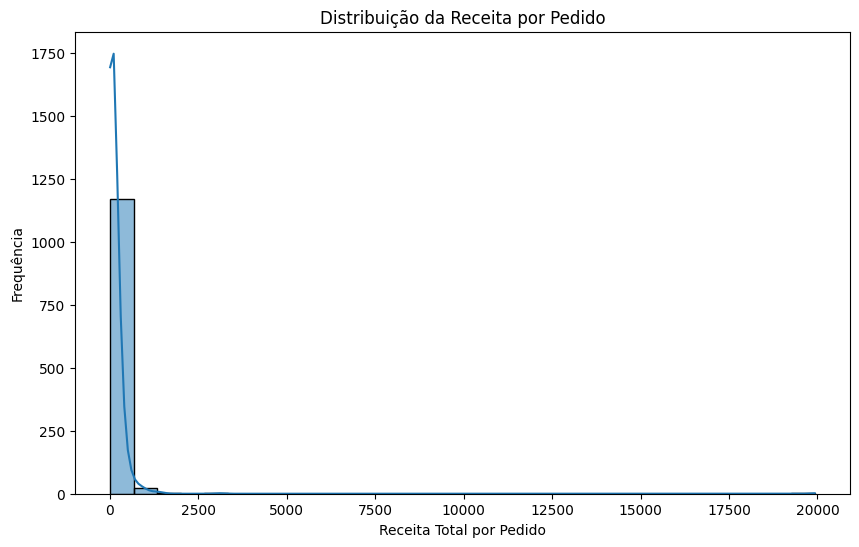

In [23]:
# plotando histograma de receita por venda
plt.figure(figsize=(10, 6))
sns.histplot(orders_price['total_revenue'], bins=30, kde=True)  
plt.title('Distribuição da Receita por Pedido')
plt.xlabel('Receita Total por Pedido')
plt.ylabel('Frequência')
plt.show()

##### A maioria das pessoas fazem pedidos de valores baixos. Logo é mais comum um maior número de vendas em baixos valores

## Tarefa 8

In [24]:
# Calculando percentil 95 e 99 de receita por pedido.
percentile_95_revenue = np.percentile(orders_price['total_revenue'], 95)
percentile_99_revenue = np.percentile(orders_price['total_revenue'], 99)
print(f'Percentil 95 de Receita por Pedido: {percentile_95_revenue}')
print(f'Percentil 99 de Receita por Pedido: {percentile_99_revenue}')

Percentil 95 de Receita por Pedido: 435.54
Percentil 99 de Receita por Pedido: 900.9039999999999


In [38]:
# Definir limite para anomalias
anomaly_threshold_revenue = percentile_95_revenue

anomalous_revenue_orders = orders_price[orders_price['total_revenue'] > anomaly_threshold_revenue]
not_anomalous_revenue_orders = orders_price[orders_price['total_revenue'] <= anomaly_threshold_revenue]
print(anomalous_revenue_orders.head())
print(not_anomalous_revenue_orders.head())

     transactionid  total_revenue
49       192721366         1450.2
81       316924019         1015.9
85       324171086          610.7
89       348143148          575.5
139      469609643          900.7
   transactionid  total_revenue
0        1062393          100.8
1        4919758           40.2
2        7210578           60.5
3        8131427           75.5
4       11068804           75.7


## Tarefa 9

In [28]:
# Encontrando a significância estatística da diferença na conversão entre os grupos usando os dados brutos
group_a_conversions = conversion_data[conversion_data['group'] == 'A']['transactionid']
group_b_conversions = conversion_data[conversion_data['group'] == 'B']['transactionid']
t_stat, p_value = stats.ttest_ind(group_a_conversions, group_b_conversions, equal_var=False)
print(f'T-statistic: {t_stat}, P-value: {p_value}')

T-statistic: -2.077902432550534, P-value: 0.04201399173051224


## Tarefa 10


In [31]:
#Encontrando a significância estatística da diferença no ticket médio do pedido entre os grupos usando os dados brutos
group_a_revenue = orders_df[orders_df['group'] == 'A']['revenue']
group_b_revenue = orders_df[orders_df['group'] == 'B']['revenue']
t_stat_revenue, p_value_revenue = stats.ttest_ind(group_a_revenue, group_b_revenue, equal_var=False)
print(f'T-statistic para receita: {t_stat_revenue}, P-value para receita: {p_value_revenue}')


T-statistic para receita: -0.8886193336529402, P-value para receita: 0.3745072295652421


## Tarefa 11

In [48]:
#Encontrando a significância estatística da diferença na conversão entre os grupos usando os dados sem anomalos.

conversions_wo_anomalies = not_anomalous_users.merge(orders_df, left_on='visitorid', right_on='visitorid', how='inner')

group_a_conversions_wo_anomalies = conversions_wo_anomalies[conversions_wo_anomalies['group'] == 'A']['transactionid']
group_b_conversions_wo_anomalies = conversions_wo_anomalies[conversions_wo_anomalies['group'] == 'B']['transactionid']
t_stat_wo_anomalies, p_value_wo_anomalies = stats.ttest_ind(group_a_conversions_wo_anomalies, group_b_conversions_wo_anomalies, equal_var=False)
print(f'T-statistic sem anomalias: {t_stat_wo_anomalies}, P-value sem anomalias: {p_value_wo_anomalies}')

T-statistic sem anomalias: -0.4095478454451126, P-value sem anomalias: 0.6822174375466237


## Tarefa 12

In [49]:
##Encontrando a significância estatística da diferença no ticket médio do pedido entre os grupos usando os dados sem anomalos.

ticket_data_wo_anomalies = not_anomalous_revenue_orders.merge(orders_df, left_on='transactionid', right_on='transactionid', how='inner')

group_a_ticket_values = ticket_data_wo_anomalies[ticket_data_wo_anomalies['group'] == 'A']['revenue']
group_b_ticket_values = ticket_data_wo_anomalies[ticket_data_wo_anomalies['group'] == 'B']['revenue']
t_stat_ticket_values, p_value_ticket_values = stats.ttest_ind(group_a_ticket_values, group_b_ticket_values, equal_var=False)
print(f'T-statistic para ticket médio filtrado: {t_stat_ticket_values}, P-value para ticket médio filtrado: {p_value_ticket_values}')

T-statistic para ticket médio filtrado: 0.24996451224452534, P-value para ticket médio filtrado: 0.8026609978395628


## Tarefa 13

##### Com base nas análises realizadas e todos os testes já feitos, considero que a diferença entre os dois resultado é muito pequena portanto indico que parem os testes sem pois não há diferença entre os grupos.